In [1]:
#if numpy error
#%pip install "numpy<2"
#%pip install --force-reinstall matplotlib

In [2]:
import numpy
print(numpy.__version__)

2.0.2


In [3]:
!ls /kaggle/input/

competitions


In [4]:
import os
import random
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from mpl_toolkits.axes_grid1 import ImageGrid

# ==========================================
# 1. Setup and Paths
# ==========================================
#Kaggle standardizes inputs under /kaggle/input/
# Assuming the dataset slug is 'vehicletype-10' based on your previous comments
BASE_DIR = '/kaggle/input/competitions/vehicle-type-10-a-dataset-for-vehicle-body-type-classification'

DATA_DIR = os.path.join(BASE_DIR, 'Data_DL_Split_80_20', 'Data_DL_Split_80_20')
TRAIN_PATH = os.path.join(DATA_DIR, 'train')
TEST_PATH = os.path.join(DATA_DIR, 'test')

# Class names extracted directly from the provided folder structure
CLASS_NAMES = [
    'bus', 'convertible', 'coupes', 'hatchback', 'pickup', 
    'sedan', 'station_wagon', 'SUV', 'trucks', 'van'
]

In [5]:
print("--- Exploratory Data Analysis ---\n")

img_exts = ('.png', '.jpg', '.jpeg', '.webp', '.bmp', '.tiff', '.tif', '.gif')

class_counts = {}
total_train_images = 0
sample_images = []

if os.path.exists(TRAIN_PATH):
    print(f"Found Training Directory: {TRAIN_PATH}\n")
    
    for class_name in CLASS_NAMES:
        class_dir = os.path.join(TRAIN_PATH, class_name)
        
        if os.path.exists(class_dir):
            # List all files that are actually images
            images = [f for f in os.listdir(class_dir) if f.lower().endswith(img_exts)]
            count = len(images)
            class_counts[class_name] = count
            total_train_images += count
            
            # Grab 2 sample images per class for the grid
            if count >= 2:
                selected = random.sample(images, 2)
                for img_name in selected:
                    img_path = os.path.join(class_dir, img_name)
                    sample_images.append(mpimg.imread(img_path))
            elif count == 1:
                img_path = os.path.join(class_dir, images[0])
                sample_images.append(mpimg.imread(img_path))
        else:
            print(f"Warning: Folder for class '{class_name}' not found in {TRAIN_PATH}")
            class_counts[class_name] = 0

    print(f"Total training images found: {total_train_images}")
    print("Images per class:")
    for name, qty in class_counts.items():
        print(f" - {name}: {qty}")

else:
    print(f"ERROR: Could not find path: {TRAIN_PATH}")
    print("Please double-check the 'Input' section on the right side of your Kaggle screen.")

# --- Test Data Evaluation ---
TEST_PATH = os.path.join(DATA_DIR, 'test')
total_test_images = 0

if os.path.exists(TEST_PATH):
    print(f"\nFound Testing Directory: {TEST_PATH}")
    
    images = [f for f in os.listdir(TEST_PATH) if f.lower().endswith(img_exts)]
    total_test_images = len(images)

    print(f"Total test images found: {total_test_images}")
else:
    print(f"\nERROR: Could not find test path: {TEST_PATH}")
    print("Please verify the folder name and location.")
    print(f"Current Working Directory: {os.getcwd()}")

--- Exploratory Data Analysis ---

Found Training Directory: /kaggle/input/competitions/vehicle-type-10-a-dataset-for-vehicle-body-type-classification/Data_DL_Split_80_20/Data_DL_Split_80_20/train

Total training images found: 802
Images per class:
 - bus: 82
 - convertible: 80
 - coupes: 80
 - hatchback: 80
 - pickup: 80
 - sedan: 80
 - station_wagon: 80
 - SUV: 80
 - trucks: 80
 - van: 80

Found Testing Directory: /kaggle/input/competitions/vehicle-type-10-a-dataset-for-vehicle-body-type-classification/Data_DL_Split_80_20/Data_DL_Split_80_20/test
Total test images found: 201



Plotting sample images (2 per class)...


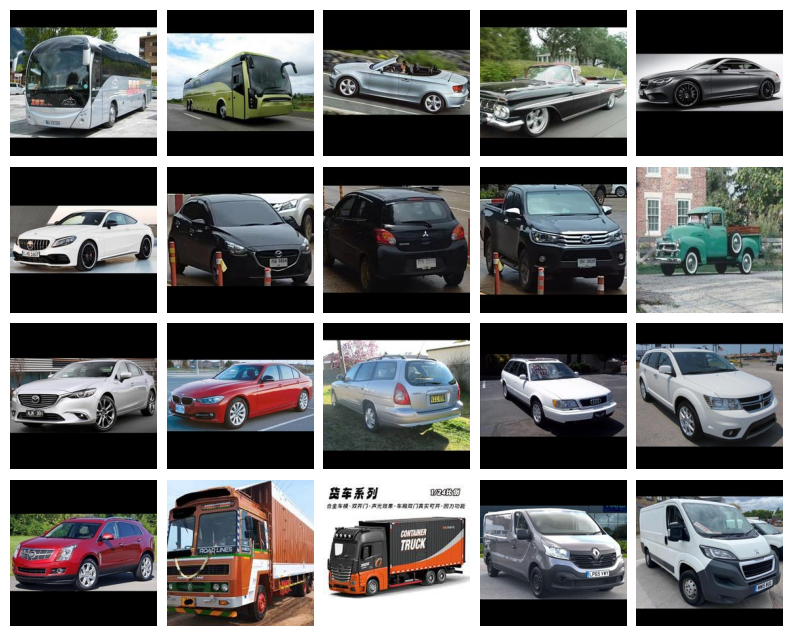

In [6]:
# ==========================================
# 3. Visualizing Sample Images (Train set)
# ==========================================
# We have 10 classes, 2 images each = 20 images.
if sample_images:
    print("\nPlotting sample images (2 per class)...")
    fig = plt.figure(figsize=(10, 8))
    
    # 4 rows, 5 columns
    grid = ImageGrid(fig, 111, nrows_ncols=(4, 5), axes_pad=0.1)

    for ax, im in zip(grid, sample_images):
        ax.imshow(im) # Removed cmap='gray' to retain the 3-channel RGB colors of the vehicles
        ax.axis('off')

    plt.show()
else:
    print("\nNo images found to plot. Attach the dataset to view the grid.")


--- Visualizing Test Images ---
Plotting 20 sample images from the test set...


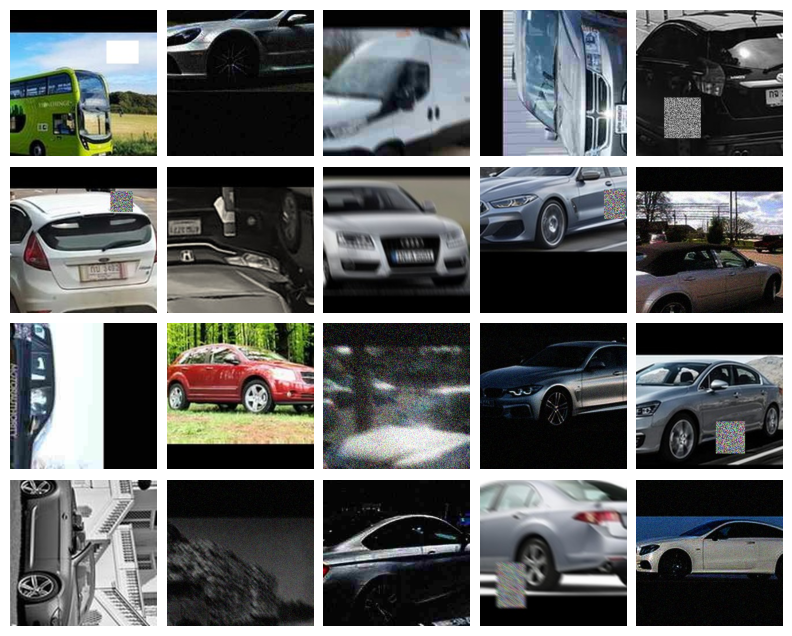

In [7]:
# ==========================================
# 3. Visualizing Sample Images (Test Set)
# ==========================================
print("\n--- Visualizing Test Images ---")

test_sample_images = []
num_images_to_plot = 20 # 4 rows, 5 columns = 20 images

if os.path.exists(TEST_PATH):
    # Grab all image files from the test directory
    test_images = [f for f in os.listdir(TEST_PATH) if f.lower().endswith(img_exts)]
    
    if test_images:
        # Sample up to 20 images (or however many exist if less than 20)
        num_samples = min(num_images_to_plot, len(test_images))
        selected_test_imgs = random.sample(test_images, num_samples)
        
        for img_name in selected_test_imgs:
            img_path = os.path.join(TEST_PATH, img_name)
            test_sample_images.append(mpimg.imread(img_path))
            
        print(f"Plotting {num_samples} sample images from the test set...")
        fig = plt.figure(figsize=(10, 8))
        
        # 4 rows, 5 columns
        grid = ImageGrid(fig, 111, nrows_ncols=(4, 5), axes_pad=0.1)

        for ax, im in zip(grid, test_sample_images):
            ax.imshow(im) 
            ax.axis('off')
            
        # Hide any unused axes if the test folder happened to have fewer than 20 images
        for ax in grid[len(test_sample_images):]:
            ax.axis('off')

        plt.show()
    else:
        print("\nNo image files found in the test directory.")
else:
    print(f"\nTest directory not found at: {TEST_PATH}")

In [8]:
# ==========================================
# 4. Random Submission Generator
# ==========================================
print("\n--- Generating Random Submission ---")

test_images = []

# Gather test images
if os.path.exists(TEST_PATH):
    # Only grab files, ignore directories if any
    test_images = [f for f in os.listdir(TEST_PATH) if os.path.isfile(os.path.join(TEST_PATH, f))]
else:
    # Dummy data for demonstration if the dataset isn't attached yet (100 test images per your spec)
    test_images = [f"{str(i).zfill(4)}.jpg" for i in range(1, 101)]

if test_images:
    # Randomly assign one of the 10 classes to each test image
    predictions = [random.choice(CLASS_NAMES) for _ in test_images]

    # Create submission dataframe according to instructions
    submission_df = pd.DataFrame({
        'image_name': test_images,
        'ground_truth': predictions
    })

    # Save to CSV
    submission_df.to_csv('submission.csv', index=False)

    print("Successfully created 'submission.csv'!")
    print("\nPreview of the submission file:")
    print(submission_df.head(10))
else:
    print("No test images found. Cannot generate submission.csv.")


--- Generating Random Submission ---
Successfully created 'submission.csv'!

Preview of the submission file:
  image_name ground_truth
0   0285.jpg       pickup
1   0498.jpg          SUV
2   0617.jpg        sedan
3   0426.jpg       coupes
4   0989.jpg       trucks
5   0235.jpg          bus
6   0700.jpg       trucks
7   0364.jpg       pickup
8   0781.jpg          van
9   0474.jpg       pickup
